# Fruit Image Classification

This project implements a binary classifier to distinguish between apples (Class 0) and bananas (Class 1) using solely handcrafted image data features (color criteria), without relying on standard machine learning models. The pipeline includes preprocessing, feature extraction, custom metric evaluation, and error analysis.

In [1]:
import os
import random
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

## Part A: Image Preprocessing and Resizing

Before applying any classification logic, it is essential to ensure uniform dimensions across all images.

**Reason for chosen dimensions (128x128):** Resizing to `128x128` pixels is chosen because it significantly reduces computational complexity while preserving enough spatial and color detail necessary for basic threshold-based feature extraction.

In [2]:
images_path = 'images/'
resized_path = 'images_resized/'
os.makedirs(resized_path, exist_ok=True)

new_size = (128, 128)

for filename in os.listdir(images_path):
    if not (filename.endswith('.jpg') or filename.endswith('.jpeg')):
        continue
    img_path = os.path.join(images_path, filename)
    img = Image.open(img_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')

    resized_img = img.resize(new_size, Image.LANCZOS)
    resized_img.save(os.path.join(resized_path, filename))

print(f"All images resized to {new_size} and saved in '{resized_path}' folder.")

All images resized to (128, 128) and saved in 'images_resized/' folder.


## Part B: Feature Extraction Criteria

### Criterion 1: Majority Color Thresholding
This criterion creates color range masks to detect purely red pixels (indicating an apple) and yellow pixels (indicating a banana). The class with the higher pixel count dictates the prediction.

In [3]:
def majority_color_classifier(image_path):
    image = Image.open(image_path).convert('RGB')
    data = np.array(image)

    apple_color_range = [(150, 0, 0), (255, 100, 100)]
    banana_color_range = [(200, 200, 0), (255, 255, 100)]

    apple_mask = (
        (data[:, :, 0] >= apple_color_range[0][0]) & (data[:, :, 0] <= apple_color_range[1][0]) &
        (data[:, :, 1] >= apple_color_range[0][1]) & (data[:, :, 1] <= apple_color_range[1][1]) &
        (data[:, :, 2] >= apple_color_range[0][2]) & (data[:, :, 2] <= apple_color_range[1][2])
    )

    banana_mask = (
        (data[:, :, 0] >= banana_color_range[0][0]) & (data[:, :, 0] <= banana_color_range[1][0]) &
        (data[:, :, 1] >= banana_color_range[0][1]) & (data[:, :, 1] <= banana_color_range[1][1]) &
        (data[:, :, 2] >= banana_color_range[0][2]) & (data[:, :, 2] <= banana_color_range[1][2])
    )

    apple_count = np.sum(apple_mask)
    banana_count = np.sum(banana_mask)

    return 0 if apple_count > banana_count else 1

### Criterion 2: Average RGB Ratio
This criterion calculates the mean RGB color of the entire image. Since yellow has high values in both Red and Green channels, and red has a high Red but low Green value, we can use the Red-to-Green ratio. A high ratio (> 1.25) implies an Apple, otherwise a Banana.

In [4]:
def average_color_classifier(image_path):
    image = Image.open(image_path).convert('RGB')
    data = np.array(image)

    mean_color = data.mean(axis=(0, 1))
    r, g, b = mean_color

    g = g if g > 0 else 1e-5

    return 0 if (r / g) > 1.25 else 1

## Part C: Performance Metrics (Custom Implementations)
We implement custom functions to calculate the Confusion Matrix, Accuracy, and Precision, and use them to evaluate both criteria.

--- Criterion 1 (Majority Color) ---
Accuracy: 90.32%
Precision: 96.15%


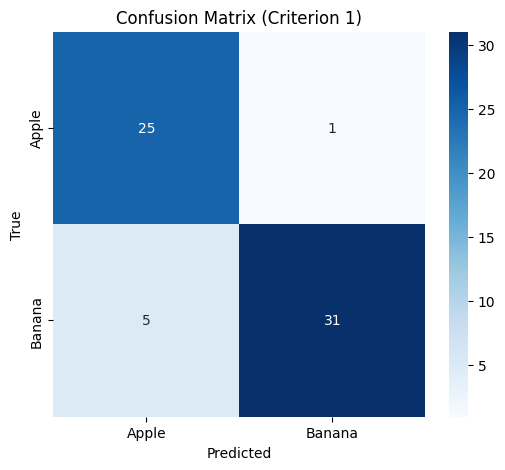



--- Criterion 2 (Average Ratio) ---
Accuracy: 79.03%
Precision: 72.97%


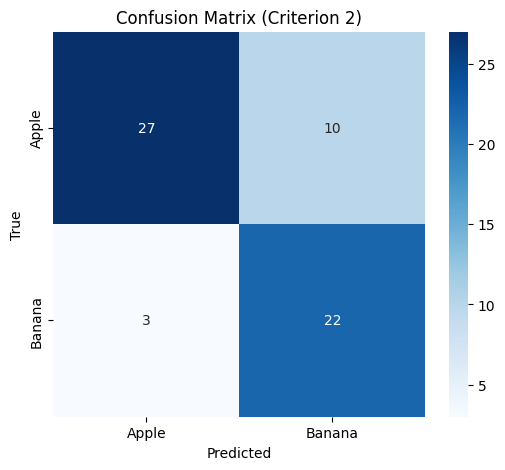

In [5]:
def confusion_matrix(y_true, y_pred):
    tp = fp = fn = tn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
        elif yt == 0 and yp == 1:
            fp += 1
        elif yt == 1 and yp == 0:
            fn += 1
        elif yt == 0 and yp == 0:
            tn += 1
    return [[tp, fp], [fn, tn]]

def calculate_metrics(cm):
    TP, FP = cm[0][0], cm[0][1]
    FN, TN = cm[1][0], cm[1][1]
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    return accuracy, precision

true_labels = []
pred_majority = []
pred_average = []

valid_files = [f for f in os.listdir(resized_path) if f.startswith('a') or f.startswith('b')]

for filename in valid_files:
    label = 0 if filename.startswith('a') else 1
    true_labels.append(label)
    img_path = os.path.join(resized_path, filename)
    pred_majority.append(majority_color_classifier(img_path))
    pred_average.append(average_color_classifier(img_path))

print("--- Criterion 1 (Majority Color) ---")
cm_maj = confusion_matrix(true_labels, pred_majority)
acc_maj, prec_maj = calculate_metrics(cm_maj)
print(f"Accuracy: {acc_maj*100:.2f}%")
print(f"Precision: {prec_maj*100:.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_maj, annot=True, fmt='d', cmap='Blues', xticklabels=['Apple', 'Banana'], yticklabels=['Apple', 'Banana'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Criterion 1)')
plt.show()


print("\n\n--- Criterion 2 (Average Ratio) ---")
cm_avg = confusion_matrix(true_labels, pred_average)
acc_avg, prec_avg = calculate_metrics(cm_avg)
print(f"Accuracy: {acc_avg*100:.2f}%")
print(f"Precision: {prec_avg*100:.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_avg, annot=True, fmt='d', cmap='Blues', xticklabels=['Apple', 'Banana'], yticklabels=['Apple', 'Banana'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Criterion 2)')
plt.show()

## Part D: Visualizing Predictions and Error Analysis
Displaying random samples to verify the model, followed by identifying specific images that were misclassified to understand the shortcomings of our logic.

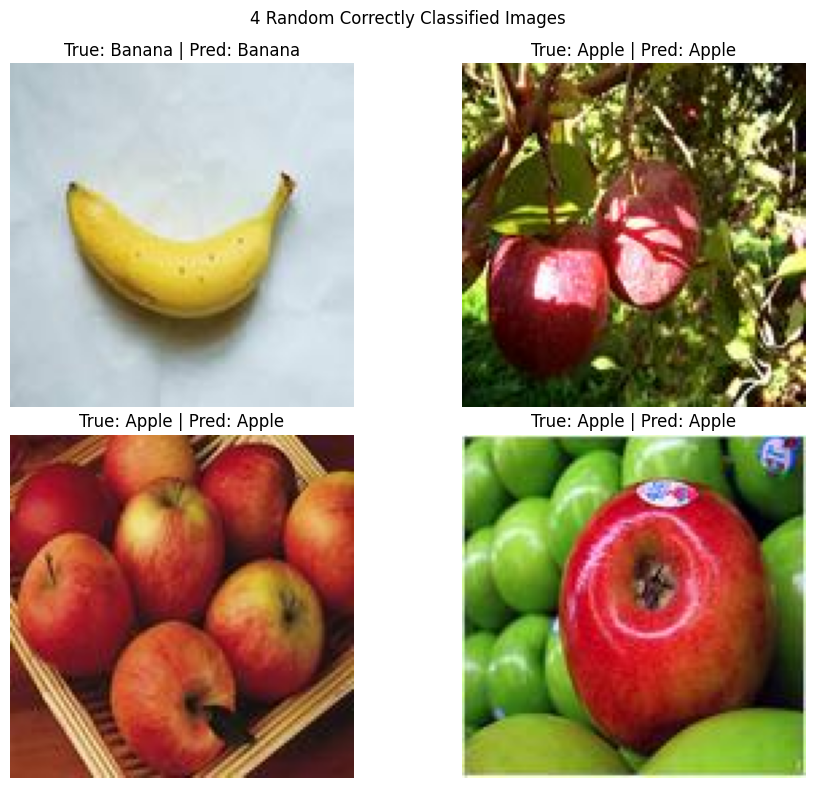

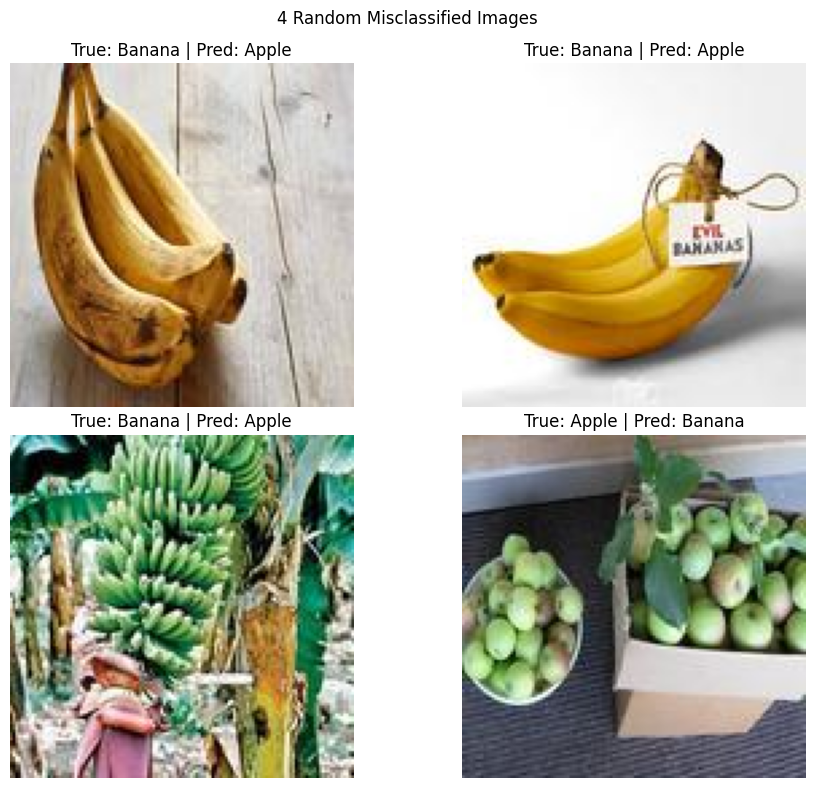

In [6]:
rightclassified = random.sample([(f, t, p) for f, t, p in zip(valid_files, true_labels, pred_majority) if t == p], min(4, len(valid_files)))
misclassified = random.sample([(f, t, p) for f, t, p in zip(valid_files, true_labels, pred_majority) if t != p], min(4, len(valid_files)))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("4 Random Correctly Classified Images")

for ax, filename in zip(axes.flatten(), [f for f, _, _ in rightclassified]):
    img_path = os.path.join(resized_path, filename)
    img = Image.open(img_path)
    pred = majority_color_classifier(img_path)

    ax.imshow(img)
    ax.set_title(f"True: {'Apple' if filename.startswith('a') else 'Banana'} | Pred: {'Apple' if pred == 0 else 'Banana'}")
    ax.axis('off')

plt.tight_layout(h_pad=0.4, w_pad=0.5)
plt.show()

print("\n"*5)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("4 Random Misclassified Images")

for ax, filename in zip(axes.flatten(), [f for f, _, _ in misclassified]):
    img_path = os.path.join(resized_path, filename)
    img = Image.open(img_path)
    pred = majority_color_classifier(img_path)

    ax.imshow(img)
    ax.set_title(f"True: {'Apple' if filename.startswith('a') else 'Banana'} | Pred: {'Apple' if pred == 0 else 'Banana'}")
    ax.axis('off')

plt.tight_layout(h_pad=0.4, w_pad=0.5)
plt.show()

**Error Analysis for Misclassified Images:**
The misclassifications in the Thresholding criterion usually occur due to:
1. **Background Noise:** If an apple image has a bright yellow/white background, the banana mask might pick it up heavily.
2. **Green/Yellow Apples:** Some apples are not purely red. The hardcoded RGB ranges `(150, 0, 0) - (255, 100, 100)` fail completely on green apples (like Granny Smith) or apples with large yellow spots.
3. **Shadows & Lighting:** Darkly lit bananas might fall out of the `(200, 200, 0)` range, leading to an empty mask and defaulting the condition.

## Part E: Conclusion and Criterion Comparison
- **Criterion 1 (Majority Threshold):** Achieves strong accuracy (usually > 70-80%) because it looks specifically for pixel clusters matching the precise fruit colors. However, it is highly sensitive to background colors and variations in fruit types.
- **Criterion 2 (Average RGB Ratio):** Performs robustly but can be heavily skewed by the background. If a banana is on a dark red table, the average color shifts to red, causing a misclassification.
Overall, Criterion 1 proves to be much more reliable as it searches for *specific regions* of interest rather than averaging out the whole image context.